# AR Catalog Tutorial

Jimmy Butler, September 2024

In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import os
from pathlib import Path
import seaborn as sns
import xarray as xr

repo_dir = str(Path(os.getcwd()).parents[0])

Dataframes are divided into years (hence just loading up the 2020 data). However, cluster labelling is consistent with previous years (so, first storm in the 2020 data will be the $n$th storm since 1980, and $n$ will be the label assigned to that storm)

In [2]:
path = repo_dir + '/data/ar_database/dataframes/2020_storm_df.pkl'
storms = pd.read_pickle(path)

Each row is a storm that was identified for that particular year.

In [3]:
storms.index

Index([7679.0, 7680.0, 7681.0, 7682.0, 7683.0, 7684.0, 7685.0, 7686.0, 7687.0,
       7688.0,
       ...
       7899.0, 7900.0, 7901.0, 7902.0, 7903.0, 7904.0, 7905.0, 7906.0, 7907.0,
       7908.0],
      dtype='float64', name='cluster', length=226)

In [4]:
storms.columns

Index(['data_array', 'is_landfalling'], dtype='object')

'data_array' column consists of xarray DataArray binary masks for each storm, with time, lat, lon dimensions properly subsetted to contain the full storm.

In [5]:
storms.data_array.iloc[13]

<xarray.DataArray 'clust' (time: 18, lats: 75, lons: 80)> Size: 108kB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
...
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=int8)
Coordinates:
  * time     (time) datetime64[ns] 144B 2020-01-30T03:00:00 ... 2020-02-01T21...
  * lats     (lats) float64 600B -76.0 -75.5 -75.0 -74.5 ... -40.0 -39.5 -39.0
  * lons     (lons) float64 640B 54.38 55.0 55.62 56.25 ... 102.5 103.1 103.8

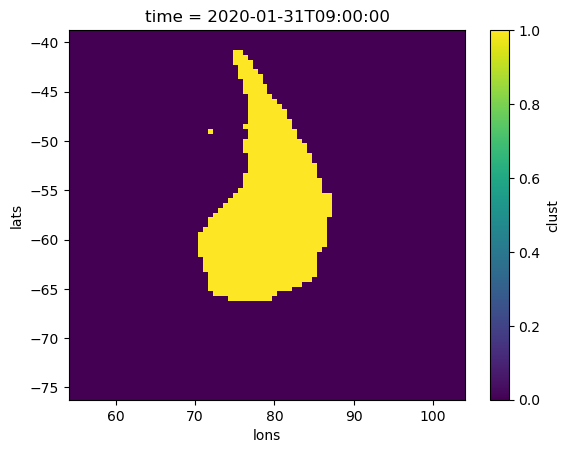

In [6]:
storms.data_array.iloc[13].isel(time=10).plot.imshow()

'is_landfalling' just indicates whether that storm makes landfall over the AIS at any point in its lifetime.

**Warning:** try to avoid printing out the dataframe or displaying it in a notebook when the 'data_array' column is included. pandas doesn't know how to display a Series whose objects are xarray DataArrays, and so it just displays a string serialization that takes FOREVER to execute. Save yourself time and exclude that column if yo